In [2]:
#ETAPA 1

import pandas as pd

# Carregar o arquivo
df = pd.read_csv("base_credito.csv")

# Mostrar a tabela completa
print(df)

       idade  renda_mensal  score_credito  historico_pagamentos  \
0         47      11522.48            634                 76.73   
1         40      13157.86            589                 90.83   
2         38       7296.76            721                 77.94   
3         42      11193.87            710                 94.09   
4         43      12798.60            576                 73.83   
...      ...           ...            ...                   ...   
49995     38       8818.70            760                 94.72   
49996     55      11501.96            728                 75.57   
49997     46       7374.09            479                 91.25   
49998     29       2290.91            739                 95.07   
49999     51       2049.86            619                 87.95   

       valor_emprestimo  
0              35229.74  
1              44177.99  
2              33868.30  
3              52289.28  
4              38663.54  
...                 ...  
49995        

In [3]:
#ETAPA 2

# Mostrar os tipos de dados de cada variável
print("Tipos de dados:")
print(df.dtypes)

# Mostrar informações gerais da base
print("\nInformações da base:")
df.info()

Tipos de dados:
idade                     int64
renda_mensal            float64
score_credito             int64
historico_pagamentos    float64
valor_emprestimo        float64
dtype: object

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB


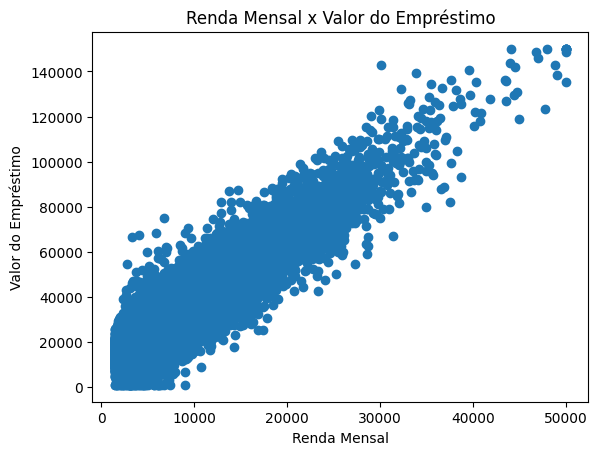

In [4]:
# Etapa 3

import matplotlib.pyplot as plt

plt.scatter(df["renda_mensal"], df["valor_emprestimo"])
plt.xlabel("Renda Mensal")
plt.ylabel("Valor do Empréstimo")
plt.title("Renda Mensal x Valor do Empréstimo")
plt.show()

In [5]:
# Etapa 4

from sklearn.model_selection import train_test_split

# Variáveis de entrada
X = df[["idade", "renda_mensal", "score_credito", "historico_pagamentos"]]

# Variável que será prevista
y = df["valor_emprestimo"]

# Divisão: 80% treinamento e 20% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dados de treinamento:", len(X_treino))
print("Dados de teste:", len(X_teste))
print("Proporção: 80% treinamento e 20% teste")

Dados de treinamento: 40000
Dados de teste: 10000
Proporção: 80% treinamento e 20% teste


In [6]:
# Etapa 5

from sklearn.linear_model import LinearRegression

# Criar o modelo
modelo = LinearRegression()

# Treinar o modelo
modelo.fit(X_treino, y_treino)

# Gerar previsões
y_pred = modelo.predict(X_teste)

print(y_pred)

[14806.33565684 29512.49287915 25840.73554724 ... 37098.02961436
 34521.68648516 42404.37788797]


In [7]:
# Etapa 6

from sklearn.metrics import mean_absolute_error, r2_score

# Calcular as métricas
mae = mean_absolute_error(y_teste, y_pred)
r2 = r2_score(y_teste, y_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 2985.9449770383862
R²: 0.9223268951278678


   Valor Real  Valor Previsto
0    22268.46    14806.335657
1    27457.59    29512.492879
2    25451.04    25840.735547
3    23890.67    21077.522905
4    27754.95    27919.314046
5    12544.92    14530.910394
6    28759.01    27385.966936
7    46454.49    41011.609092
8    43199.01    36525.087756
9    34051.39    35786.960945


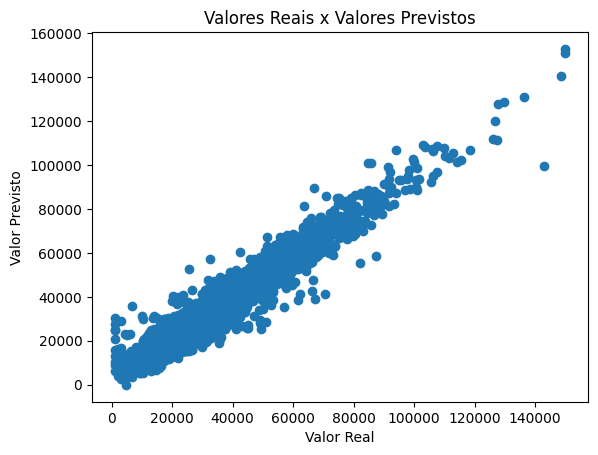

In [8]:
# Etapa 7

comparacao = pd.DataFrame({
    "Valor Real": y_teste.values,
    "Valor Previsto": y_pred
})

print(comparacao.head(10))

plt.scatter(y_teste, y_pred)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Valores Reais x Valores Previstos")
plt.show()

In [10]:
# Etapa 8

# Características de um novo cliente
novo_cliente = pd.DataFrame({
    "idade": [30],
    "renda_mensal": [5000],
    "score_credito": [650],
    "historico_pagamentos": [90]
})

# Fazer a previsão
previsao = modelo.predict(novo_cliente)

print("Características do novo cliente:")
print(novo_cliente)

print("\nValor previsto do empréstimo: R$", round(previsao[0], 2))

print("\nInterpretação:")
print("Esse cliente poderá receber aproximadamente R$",
      round(previsao[0], 2), "de empréstimo.")

Características do novo cliente:
   idade  renda_mensal  score_credito  historico_pagamentos
0     30          5000            650                    90

Valor previsto do empréstimo: R$ 24824.26

Interpretação:
Esse cliente poderá receber aproximadamente R$ 24824.26 de empréstimo.


ETAPA 9

O modelo de regressão apresentou resultados adequados para estimar o valor dos empréstimos, considerando os resultados obtidos nas métricas de avaliação. Porém, ele possui algumas limitações, como a dependência da qualidade e quantidade dos dados utilizados. Além disso, por ser uma regressão linear, o modelo considera relações lineares entre as variáveis, podendo apresentar erros em casos de clientes com características muito diferentes das presentes na base.